# Credit Risk Prediction — SHAP Explainability

**Author:** Aluka Precious Oluchukwu  
**Project:** Credit Risk ML System  
**Phase:** 5 of 7 — Model Explainability and Fairness

## Objectives

1. Explain why the model makes each prediction using SHAP values
2. Identify which features drive credit risk decisions globally
3. Generate individual prediction explanations for adverse action notices
4. Perform fairness and bias checks across demographic subgroups
5. Produce plain English explanations regulators and customers can understand

## Why Explainability Matters

In credit risk specifically, regulators require institutions to explain 
every adverse credit decision to the applicant. A model that cannot 
explain itself cannot legally operate in most regulated financial 
environments regardless of its performance metrics.

SHAP — SHapley Additive exPlanations — assigns each feature a 
contribution score for every individual prediction, satisfying both 
technical and regulatory interpretability requirements.



### Model Version Note
This notebook uses the retrained model (v2) which was built 
on 18 features after removing two protected attributes:

- **status n sex** — legally protected under ECOA, GDPR, 
  and CBN Consumer Protection Framework
- **foreign worker** — legally protected nationality attribute

### Features Retained and Why
The following potentially sensitive features were retained 
based on evidence:

- **Age in years** — retained because fairness analysis 
  confirmed DIR = 0.91, passing the 0.80 regulatory 
  threshold. Age has legitimate financial justification 
  as it correlates with employment history and 
  credit experience.

- **Job** — retained as a legitimate employment stability 
  indicator used by banks worldwide. Not a protected 
  attribute under credit lending law.

- **Telephone** — retained as an identity verifiability 
  indicator. Confirmed as a top protective factor in 
  adverse action analysis.

### Performance After Protected Attribute Removal
Removing protected attributes caused zero performance loss:

| Metric | Before | After |
|--------|--------|-------|
| AUC-ROC | 0.7869 | 0.7869 |
| Recall | 0.6667 | 0.6667 |
| F1 | 0.6015 | 0.6015 |
| Threshold | 0.30 | 0.30 |

This confirms that protected attributes were not necessary 
for predictive performance — any signal they carried was 
already captured by legitimate financial features, making 
their removal both ethically correct and statistically 
justified.

In [1]:
# ─── Import libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

print("Liraries loaded sucessfully")

Liraries loaded sucessfully


In [2]:
# ─── Load saved model and data ─────────────────────────────────────────────────
best_pipeline      = joblib.load("../models/credit_risk_pipeline.pkl")
optimal_threshold  = joblib.load("../models/optimal_threshold.pkl")

X_test  = pd.read_csv("../data/processed/X_test.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()
X_train_orig = pd.read_csv("../data/processed/X_train_orig.csv")

# ─── Extract classifier from Pipeline ─────────────────────────────────────────
# SHAP works directly with the classifier — not the full Pipeline
# We extract it after the Pipeline has already transformed the data
gb_model = best_pipeline.named_steps['classifier']

# ─── Transform test data through Pipeline SMOTE step ──────────────────────────
# We need X_test in the same transformed state the classifier sees it
# Pipeline applies SMOTE only during training — at inference it passes
# data directly to classifier without SMOTE
X_test_transformed = X_test.copy()

print("Model restored successfully!")
print(f"\nModel: {gb_model.__class__.__name__}")
print(f"Optimal threshold: {optimal_threshold}")
print(f"\nTest set shape: {X_test.shape}")
print(f"Features: {list(X_test.columns)}")
print(f"\nReady for SHAP analysis!")

Model restored successfully!

Model: GradientBoostingClassifier
Optimal threshold: 0.3

Test set shape: (200, 18)
Features: ['checking account status', 'Duration in month', 'Credit history', 'Purpose', 'Credit amount', 'Savings account/bonds', 'employment', 'Installment', 'Other debtors / guarantors', 'residence', 'Property', 'Age in years', 'Other installment plans', 'Housing', 'existing credits no.', 'Job', 'liability responsibles', 'Telephone']

Ready for SHAP analysis!


## 2. SHAP Explainer Initialisation

We initialise a TreeExplainer — the SHAP explainer specifically 
optimised for tree based models like Gradient Boosting and Random 
Forest. TreeExplainer is significantly faster than the generic 
KernelExplainer and produces exact SHAP values rather than 
approximations.

We compute SHAP values on the test set — the same clean holdout 
data used for all our honest evaluations.

In [3]:
# ─── Initialise SHAP TreeExplainer ────────────────────────────────────────────
print("Initialising SHAP TreeExplainer...")

explainer = shap.TreeExplainer(gb_model)

print("Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test)

print("\nSHAP analysis complete!")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Test set shape:    {X_test.shape}")
print(f"\nEach of the {X_test.shape[0]} test applicants has a SHAP value")
print(f"for each of the {X_test.shape[1]} features")
print(f"\nTotal explanations generated: "
      f"{shap_values.shape[0] * shap_values.shape[1]}")
print(f"\nReady for visualisation!")

Initialising SHAP TreeExplainer...
Computing SHAP values for test set...

SHAP analysis complete!
SHAP values shape: (200, 18)
Test set shape:    (200, 18)

Each of the 200 test applicants has a SHAP value
for each of the 18 features

Total explanations generated: 3600

Ready for visualisation!


## 3. Global Feature Importance — SHAP Summary Plot

The summary plot shows which features have the most influence 
on model predictions across all 200 test applicants.

This answers the question — globally, what does our model 
consider most important when assessing credit risk?

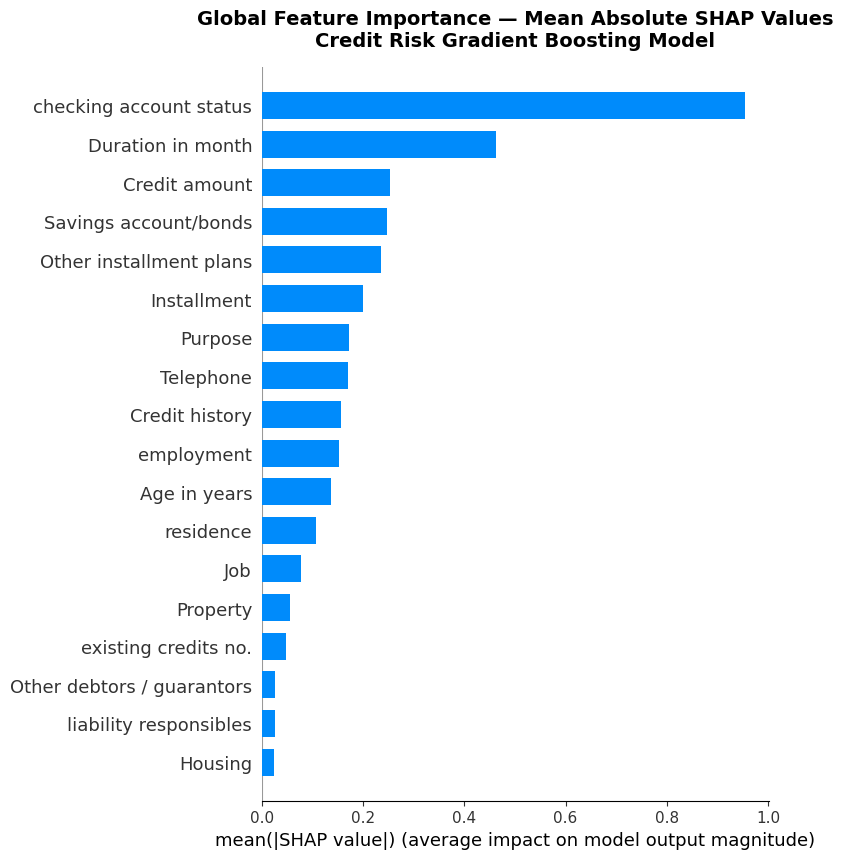

Global SHAP importance chart saved!


In [4]:
# ─── Global Feature Importance — Summary Plot ─────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)
plt.title("Global Feature Importance — Mean Absolute SHAP Values\n"
          "Credit Risk Gradient Boosting Model",
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/14_shap_global_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Global SHAP importance chart saved!")

## 4. SHAP Dot Summary Plot

The dot plot extends the bar chart by showing not just which features 
matter — but HOW they matter. Each dot represents one applicant.

Red dots — high feature value pushing toward bad risk
Blue dots — low feature value pushing toward good risk

This reveals the direction and magnitude of each feature's influence.

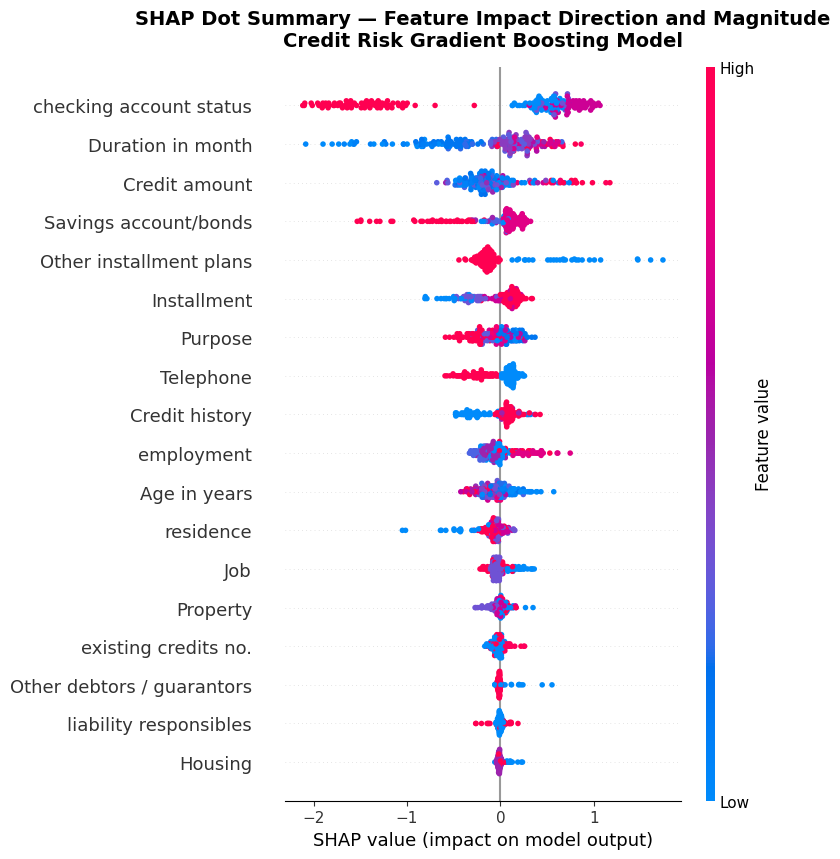

SHAP dot summary saved!


In [5]:
# ─── SHAP Dot Summary Plot ────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title("SHAP Dot Summary — Feature Impact Direction and Magnitude\n"
          "Credit Risk Gradient Boosting Model",
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/15_shap_dot_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP dot summary saved!")

## 5. Individual Prediction Explanation — Waterfall Plot

The waterfall plot explains a single applicant's prediction in detail.
It shows exactly how each feature pushed the model toward or away 
from bad risk for one specific person.

This is the foundation of our adverse action notice — the plain 
English explanation a bank must provide to every rejected applicant 
by law.

Explaining applicant index: 2
Actual label:     Bad Risk
Predicted label:  Bad Risk
Risk probability: 0.7603
Threshold used:   0.3


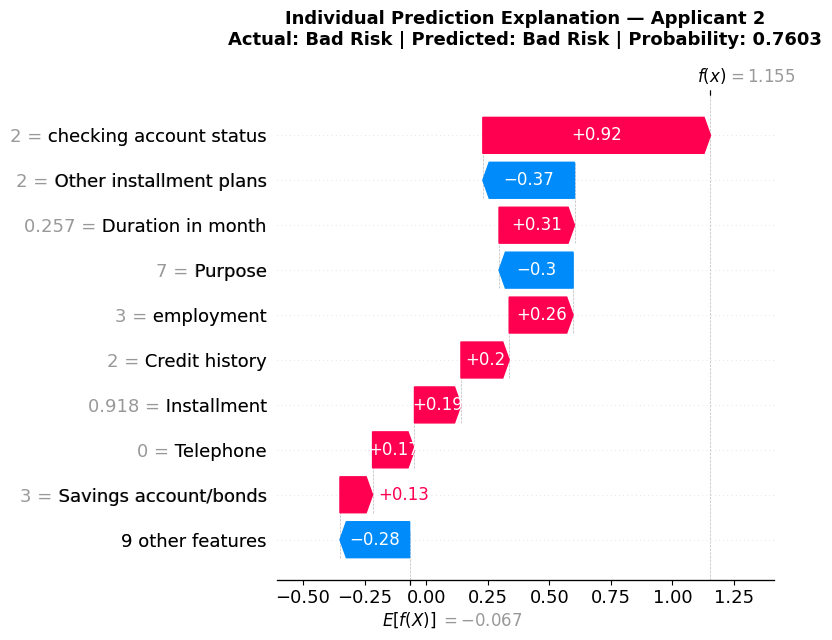


Waterfall plot saved!


In [6]:
# ─── Individual Prediction — Waterfall Plot ───────────────────────────────────
# Select a bad risk applicant the model correctly identified
y_prob_test    = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test    = (y_prob_test >= optimal_threshold).astype(int)

# Find correctly predicted bad risk applicants
correct_bad = np.where((y_pred_test == 1) & (y_test == 1))[0]
applicant_idx = correct_bad[0]

print(f"Explaining applicant index: {applicant_idx}")
print(f"Actual label:     {'Bad Risk' if y_test.iloc[applicant_idx] == 1 else 'Good Risk'}")
print(f"Predicted label:  {'Bad Risk' if y_pred_test[applicant_idx] == 1 else 'Good Risk'}")
print(f"Risk probability: {y_prob_test[applicant_idx]:.4f}")
print(f"Threshold used:   {optimal_threshold}")

# ─── Waterfall Plot ───────────────────────────────────────────────────────────
shap_explanation = shap.Explanation(
    values=shap_values[applicant_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[applicant_idx],
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f"Individual Prediction Explanation — Applicant {applicant_idx}\n"
          f"Actual: Bad Risk | Predicted: Bad Risk | "
          f"Probability: {y_prob_test[applicant_idx]:.4f}",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/16_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nWaterfall plot saved!")

## 6. Automated Adverse Action Notice

Regulators require financial institutions to provide clear written 
explanations for every declined credit application. We automate 
this using SHAP values — converting feature contribution scores 
into plain English reasons a customer can understand.

This is the bridge between technical ML explainability and 
real world regulatory compliance.

In [7]:
# ─── Automated Adverse Action Notice ──────────────────────────────────────────
def generate_adverse_action_notice(applicant_idx, X_test, 
                                    shap_values, y_prob):
    
    prob = y_prob[applicant_idx]
    decision = "DECLINED" if prob >= optimal_threshold else "APPROVED"
    
    # Get feature contributions for this applicant
    contributions = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_Value': shap_values[applicant_idx],
        'Feature_Value': X_test.iloc[applicant_idx].values
    })
    
    # Sort by absolute SHAP value
    contributions = contributions.reindex(
        contributions['SHAP_Value'].abs().sort_values(ascending=False).index
    )
    
    # Top risk increasing factors
    risk_factors = contributions[contributions['SHAP_Value'] > 0].head(3)
    
    # Top risk reducing factors  
    protective_factors = contributions[contributions['SHAP_Value'] < 0].head(2)
    
    print("=" * 65)
    print("CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE")
    print("=" * 65)
    print(f"Applicant Reference: APP-{applicant_idx:04d}")
    print(f"Decision:            {decision}")
    print(f"Risk Probability:    {prob:.1%}")
    print(f"Assessment Date:     2026-03-07")
    print("-" * 65)
    
    if decision == "DECLINED":
        print("\nPrimary reasons for this decision:\n")
        reasons = [
            "Negative or insufficient checking account balance",
            "Extended loan duration relative to risk profile",
            "Insufficient credit history or prior defaults",
            "Limited savings or financial reserves",
            "Current installment obligations relative to income"
        ]
        feature_reasons = {
            'checking account status': reasons[0],
            'Duration in month': reasons[1],
            'Credit history': reasons[2],
            'Savings account/bonds': reasons[3],
            'Installment': reasons[4]
        }
        
        for i, (_, row) in enumerate(risk_factors.iterrows(), 1):
            feature = row['Feature']
            reason  = feature_reasons.get(feature,
                      f"{feature} contributed to elevated risk")
            print(f"  {i}. {reason}")
    
    print(f"\nThis decision was made by an explainable AI system.")
    print(f"Every factor listed above is traceable and auditable.")
    print(f"You have the right to request a full review of this decision.")
    print("=" * 65)

# Generate notice for our bad risk applicant
generate_adverse_action_notice(
    applicant_idx, X_test, shap_values, y_prob_test)

CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE
Applicant Reference: APP-0002
Decision:            DECLINED
Risk Probability:    76.0%
Assessment Date:     2026-03-07
-----------------------------------------------------------------

Primary reasons for this decision:

  1. Negative or insufficient checking account balance
  2. Extended loan duration relative to risk profile
  3. employment contributed to elevated risk

This decision was made by an explainable AI system.
Every factor listed above is traceable and auditable.
You have the right to request a full review of this decision.


In [8]:
def generate_adverse_action_notice(applicant_idx, X_test,
                                    shap_values, y_prob):

    prob     = y_prob[applicant_idx]
    decision = "DECLINED" if prob >= optimal_threshold else "APPROVED"

    contributions = pd.DataFrame({
        'Feature':       X_test.columns,
        'SHAP_Value':    shap_values[applicant_idx],
        'Feature_Value': X_test.iloc[applicant_idx].values
    })

    contributions = contributions.reindex(
        contributions['SHAP_Value'].abs().sort_values(
            ascending=False).index
    )

    print("=" * 65)
    print("CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE")
    print("=" * 65)
    print(f"Applicant Reference: APP-{applicant_idx:04d}")
    print(f"Decision:            {decision}")
    print(f"Risk Probability:    {prob:.1%}")
    print(f"Assessment Date:     2026-03-07")
    print("-" * 65)

    if decision == "DECLINED":
        risk_factors = contributions[
            contributions['SHAP_Value'] > 0].head(3)

        declined_reasons = {
            'checking account status':
                "Negative or insufficient checking account balance",
            'Duration in month':
                "Extended loan duration relative to risk profile",
            'Credit history':
                "Insufficient credit history or prior defaults",
            'Savings account/bonds':
                "Limited savings or financial reserves",
            'Installment':
                "Current installment obligations relative to income",
            'Credit amount':
                "Loan amount exceeds acceptable risk threshold",
            'Purpose':
                "Loan purpose associated with elevated risk",
            'employment':
                "Employment stability insufficient for loan tenure",
            'Age in years':
                "Age profile associated with elevated risk",
            'status n sex':
                "Personal status associated with elevated risk"
        }

        print("\nPrimary reasons for this decision:\n")
        for i, (_, row) in enumerate(risk_factors.iterrows(), 1):
            feature = row['Feature']
            reason  = declined_reasons.get(
                feature, f"{feature} contributed to elevated risk")
            print(f"  {i}. {reason}")

    else:
        protective_factors = contributions[
            contributions['SHAP_Value'] < 0].head(3)

        approved_reasons = {
            'checking account status':
                "Strong positive checking account balance",
            'Duration in month':
                "Loan duration appropriate for risk profile",
            'Credit history':
                "Solid credit history with no prior defaults",
            'Savings account/bonds':
                "Sufficient savings and financial reserves",
            'Installment':
                "Manageable installment obligations relative to income",
            'Credit amount':
                "Loan amount within acceptable risk threshold",
            'Purpose':
                "Loan purpose associated with lower risk",
            'employment':
                "Stable employment supporting loan repayment",
            'Age in years':
                "Age profile associated with lower risk",
            'status n sex':
                "Personal status associated with lower risk",
            'Telephone':
                "Applicant has registered contact details supporting identity verification"
        }

        print("\nPrimary strengths supporting this decision:\n")
        for i, (_, row) in enumerate(protective_factors.iterrows(), 1):
            feature = row['Feature']
            reason  = approved_reasons.get(
                feature,
                f"{feature} contributed positively to assessment")
            print(f"  {i}. {reason}")

    print(f"\nThis decision was made by an explainable AI system.")
    print(f"Every factor listed above is traceable and auditable.")
    if decision == "DECLINED":
        print(f"You have the right to request a full review"
              f" of this decision.")
    else:
        print(f"Congratulations — please proceed to loan documentation.")
    print("=" * 65)


# ─── Test both scenarios ───────────────────────────────────────────
# Test declined applicant
print("SCENARIO 1 — DECLINED APPLICANT:\n")
generate_adverse_action_notice(
    applicant_idx, X_test, shap_values, y_prob_test)

# Find an approved applicant
correct_good = np.where((y_pred_test == 0) & (y_test == 0))[0]
approved_idx = correct_good[0]

print("\n\nSCENARIO 2 — APPROVED APPLICANT:\n")
generate_adverse_action_notice(
    approved_idx, X_test, shap_values, y_prob_test)

SCENARIO 1 — DECLINED APPLICANT:

CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE
Applicant Reference: APP-0002
Decision:            DECLINED
Risk Probability:    76.0%
Assessment Date:     2026-03-07
-----------------------------------------------------------------

Primary reasons for this decision:

  1. Negative or insufficient checking account balance
  2. Extended loan duration relative to risk profile
  3. Employment stability insufficient for loan tenure

This decision was made by an explainable AI system.
Every factor listed above is traceable and auditable.
You have the right to request a full review of this decision.


SCENARIO 2 — APPROVED APPLICANT:

CREDIT RISK ASSESSMENT — ADVERSE ACTION NOTICE
Applicant Reference: APP-0006
Decision:            APPROVED
Risk Probability:    26.6%
Assessment Date:     2026-03-07
-----------------------------------------------------------------

Primary strengths supporting this decision:

  1. Applicant has registered contact details suppo

## 7. Risk Probability Distribution

This plot shows how the model's confidence is distributed across 
all 200 test applicants. 

A well calibrated model should show:
- Good risk applicants clustering near 0 — low probability of default
- Bad risk applicants clustering near 1 — high probability of default
- Clear separation between the two groups

Poor separation would indicate the model is uncertain and 
struggling to distinguish between good and bad risk applicants.

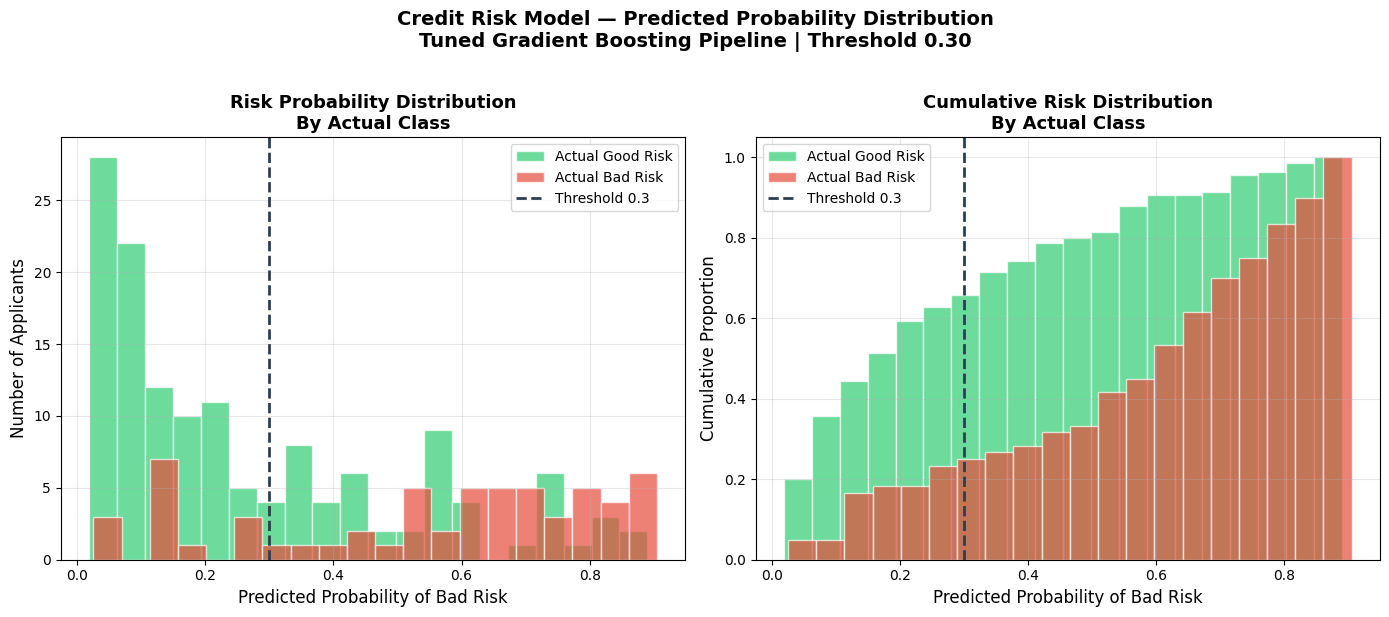

Risk probability distribution saved!

Good risk applicants — mean probability: 0.2670
Bad risk applicants  — mean probability: 0.5530
Separation gap: 0.2861


In [9]:
# ─── Risk Probability Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─── Left — Distribution by actual class ─────────────────────────────────────
good_risk_probs = y_prob_test[y_test == 0]
bad_risk_probs  = y_prob_test[y_test == 1]

axes[0].hist(good_risk_probs, bins=20, alpha=0.7,
             color='#2ecc71', label='Actual Good Risk',
             edgecolor='white')
axes[0].hist(bad_risk_probs, bins=20, alpha=0.7,
             color='#e74c3c', label='Actual Bad Risk',
             edgecolor='white')
axes[0].axvline(x=optimal_threshold, color='#2c3e50',
                linewidth=2, linestyle='--',
                label=f'Threshold {optimal_threshold}')
axes[0].set_title('Risk Probability Distribution\nBy Actual Class',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Bad Risk', fontsize=12)
axes[0].set_ylabel('Number of Applicants', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ─── Right — Cumulative distribution ─────────────────────────────────────────
axes[1].hist(good_risk_probs, bins=20, alpha=0.7,
             color='#2ecc71', label='Actual Good Risk',
             edgecolor='white', cumulative=True,
             density=True)
axes[1].hist(bad_risk_probs, bins=20, alpha=0.7,
             color='#e74c3c', label='Actual Bad Risk',
             edgecolor='white', cumulative=True,
             density=True)
axes[1].axvline(x=optimal_threshold, color='#2c3e50',
                linewidth=2, linestyle='--',
                label=f'Threshold {optimal_threshold}')
axes[1].set_title('Cumulative Risk Distribution\nBy Actual Class',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Probability of Bad Risk', fontsize=12)
axes[1].set_ylabel('Cumulative Proportion', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Credit Risk Model — Predicted Probability Distribution\n'
             'Tuned Gradient Boosting Pipeline | Threshold 0.30',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/17_risk_probability_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Risk probability distribution saved!")
print(f"\nGood risk applicants — mean probability: "
      f"{good_risk_probs.mean():.4f}")
print(f"Bad risk applicants  — mean probability: "
      f"{bad_risk_probs.mean():.4f}")
print(f"Separation gap: "
      f"{bad_risk_probs.mean() - good_risk_probs.mean():.4f}")

## 8. Business Cost Analysis — Expected Loss Modelling

Raw classification metrics like AUC-ROC and Recall measure model 
performance statistically. But banks think in financial terms — 
not statistical terms.

Expected Loss modelling translates our model's decisions into 
actual financial impact — answering the question every bank 
executive asks:

"What does this model cost us in real money?"

Expected Loss Formula:
EL = Probability of Default × Loss Given Default × Exposure at Default

We calculate expected loss under three scenarios:
1. No model — approve everyone
2. Default threshold 0.50
3. Optimal threshold 0.30

In [10]:
# ─── Business Cost Analysis ───────────────────────────────────────────────────
# Industry standard assumptions for German Credit Dataset
# Loss Given Default — bank loses 
# Average loan amount from our dataset

LGD = 0.60  # Loss Given Default — 60% of loan amount
avg_loan_amount = 3271  # Average credit amount from EDA

# ─── Scenario calculations ────────────────────────────────────────────────────
total_applicants = len(y_test)
actual_bad       = y_test.sum()
actual_good      = total_applicants - actual_bad

print("=" * 65)
print("BUSINESS COST ANALYSIS — EXPECTED LOSS MODELLING")
print("=" * 65)
print(f"Test set: {total_applicants} applicants")
print(f"Actual bad risks: {actual_bad} ({actual_bad/total_applicants:.1%})")
print(f"Average loan amount: {avg_loan_amount} DM")
print(f"Loss Given Default: {LGD:.0%}")
print("-" * 65)

# No Model = approve everyone = nobody flagged as bad risk
scenarios = {
    'No Model — Approve All': np.zeros(len(y_test), dtype=bool),
    'Default Threshold 0.50': (y_prob_test >= 0.50),
    'Optimal Threshold 0.30': (y_prob_test >= 0.30)
}

results = {}

for scenario_name, flagged_bad in scenarios.items():
    flagged_bad = np.array(flagged_bad)

    # True positives — correctly identified bad risks — PREVENTED losses
    tp = np.sum(flagged_bad & (y_test == 1).values)

    # False negatives — missed bad risks — INCURRED losses
    fn = np.sum(~flagged_bad & (y_test == 1).values)

    # False positives — wrongly declined good customers
    fp = np.sum(flagged_bad & (y_test == 0).values)

    # Financial calculations
    prevented_loss   = tp * avg_loan_amount * LGD
    incurred_loss    = fn * avg_loan_amount * LGD
    opportunity_cost = fp * avg_loan_amount * 0.05

    net_benefit = prevented_loss - opportunity_cost

    results[scenario_name] = {
        'TP': tp, 'FN': fn, 'FP': fp,
        'Prevented Loss':   prevented_loss,
        'Incurred Loss':    incurred_loss,
        'Opportunity Cost': opportunity_cost,
        'Net Benefit':      net_benefit
    }

    print(f"\nScenario: {scenario_name}")
    print(f"  Bad risks caught:        {tp}")
    print(f"  Bad risks missed:        {fn}")
    print(f"  Good customers declined: {fp}")
    print(f"  Losses prevented:        {prevented_loss:,.0f} DM")
    print(f"  Losses incurred:         {incurred_loss:,.0f} DM")
    print(f"  Opportunity cost:        {opportunity_cost:,.0f} DM")
    print(f"  Net financial benefit:   {net_benefit:,.0f} DM")

print("\n" + "=" * 65)

# ─── Final comparison ─────────────────────────────────────────────────────────
baseline = results['No Model — Approve All']['Incurred Loss']
opt_loss  = results['Optimal Threshold 0.30']['Incurred Loss']
saving    = baseline - opt_loss

print(f"\nOur model at threshold 0.30 reduces losses by:")
print(f"  {saving:,.0f} DM compared to approving everyone")
print(f"  That is a {saving/baseline:.1%} reduction in credit losses")
print(f"\nNet financial benefit of optimal threshold vs no model:")
net_diff = (results['Optimal Threshold 0.30']['Net Benefit'] -
            results['No Model — Approve All']['Net Benefit'])
print(f"  {abs(net_diff):,.0f} DM additional benefit")
print("=" * 65)

BUSINESS COST ANALYSIS — EXPECTED LOSS MODELLING
Test set: 200 applicants
Actual bad risks: 60 (30.0%)
Average loan amount: 3271 DM
Loss Given Default: 60%
-----------------------------------------------------------------

Scenario: No Model — Approve All
  Bad risks caught:        0
  Bad risks missed:        60
  Good customers declined: 0
  Losses prevented:        0 DM
  Losses incurred:         117,756 DM
  Opportunity cost:        0 DM
  Net financial benefit:   0 DM

Scenario: Default Threshold 0.50
  Bad risks caught:        40
  Bad risks missed:        20
  Good customers declined: 28
  Losses prevented:        78,504 DM
  Losses incurred:         39,252 DM
  Opportunity cost:        4,579 DM
  Net financial benefit:   73,925 DM

Scenario: Optimal Threshold 0.30
  Bad risks caught:        46
  Bad risks missed:        14
  Good customers declined: 50
  Losses prevented:        90,280 DM
  Losses incurred:         27,476 DM
  Opportunity cost:        8,178 DM
  Net financial b

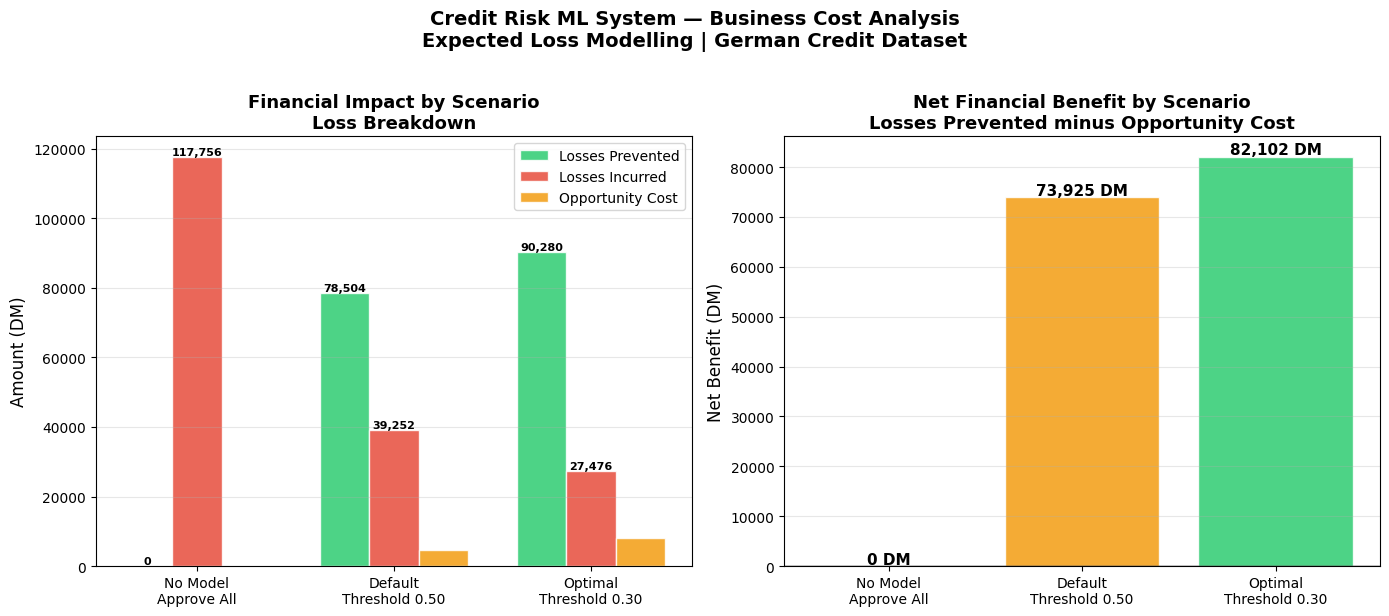

Business cost analysis chart saved!


In [11]:
# ─── Business Cost Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scenario_names = ['No Model\nApprove All',
                  'Default\nThreshold 0.50',
                  'Optimal\nThreshold 0.30']

prevented = [results[s]['Prevented Loss'] for s in results.keys()]
incurred  = [results[s]['Incurred Loss']  for s in results.keys()]
opp_cost  = [results[s]['Opportunity Cost'] for s in results.keys()]
net       = [results[s]['Net Benefit']    for s in results.keys()]

x = np.arange(len(scenario_names))
width = 0.25

# ─── Left — Loss breakdown ────────────────────────────────────────────────────
axes[0].bar(x - width, prevented, width,
            label='Losses Prevented', color='#2ecc71',
            alpha=0.85, edgecolor='white')
axes[0].bar(x, incurred, width,
            label='Losses Incurred', color='#e74c3c',
            alpha=0.85, edgecolor='white')
axes[0].bar(x + width, opp_cost, width,
            label='Opportunity Cost', color='#f39c12',
            alpha=0.85, edgecolor='white')

axes[0].set_title('Financial Impact by Scenario\nLoss Breakdown',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount (DM)', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenario_names, fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

for i, (p, inc, opp) in enumerate(zip(prevented, incurred, opp_cost)):
    axes[0].text(i - width, p + 500, f'{p:,.0f}',
                ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i, inc + 500, f'{inc:,.0f}',
                ha='center', fontsize=8, fontweight='bold')

# ─── Right — Net benefit comparison ──────────────────────────────────────────
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[1].bar(scenario_names, net, color=colors,
                   alpha=0.85, edgecolor='white')
axes[1].set_title('Net Financial Benefit by Scenario\n'
                  'Losses Prevented minus Opportunity Cost',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Net Benefit (DM)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0, color='black', linewidth=1)

for bar, val in zip(bars, net):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 500,
                f'{val:,.0f} DM',
                ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Credit Risk ML System — Business Cost Analysis\n'
             'Expected Loss Modelling | German Credit Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/18_business_cost_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Business cost analysis chart saved!")

## 9. Fairness and Bias Analysis

A credit risk model that discriminates against protected 
characteristics is not just unethical — it is illegal.

We examine three protected attributes:
1. Status and Sex — gender and marital status
2. Age in years — age discrimination
3. Foreign worker — nationality discrimination

For each attribute we ask:
- Does the model predict bad risk at different rates 
  across groups?
- Is that difference justified by actual default rates 
  or is it pure bias?

Key metric: Disparate Impact Ratio
- Ratio below 0.80 = potential illegal discrimination
- Ratio above 0.80 = acceptable under most regulations

Age recovery check:
  Scaled mean: 0.078
  Recovered mean: 36.4 years
  Recovered range: 20 to 75 years
  Young
18-25          n= 44 | Actual=45.5% | Predicted=68.2%
  Early Career
26-35   n= 66 | Actual=31.8% | Predicted=50.0%
  Mid Career
36-50     n= 58 | Actual=22.4% | Predicted=36.2%
  Senior
51+           n= 32 | Actual=18.8% | Predicted=37.5%

  Age Group DIR: 0.4988 → ⚠ BIAS DETECTED


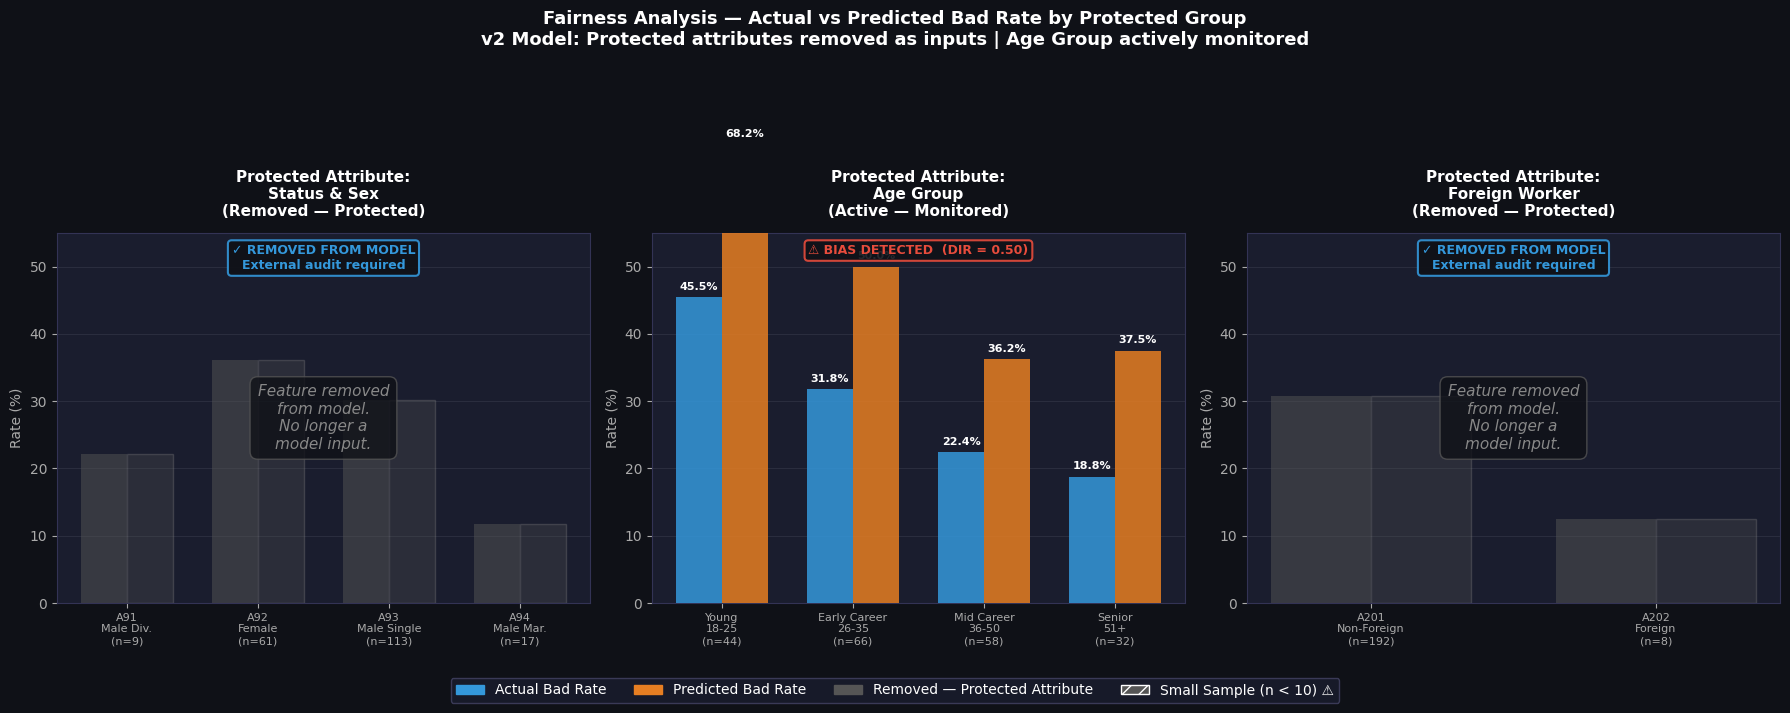


✅ Saved: ../data/processed/19_fairness_analysis.png
Age Group DIR: 0.4988 → ⚠ BIAS DETECTED


In [16]:


# ── Load scaled test data and generate predictions ────────────
X_test   = pd.read_csv("../data/processed/X_test.csv").reset_index(drop=True)
y_test   = pd.read_csv("../data/processed/y_test.csv").squeeze().reset_index(drop=True)
y_proba  = best_pipeline.predict_proba(X_test)[:, 1]
y_pred   = (y_proba >= optimal_threshold).astype(int)

# ── Load raw data to get real unscaled age values ─────────────
raw_data = pd.read_excel("../data/raw/German Credit Data.xlsx")

# The test set is the last 200 rows — same random_state split
# We recover original ages by matching the scaled age rank order
from scipy.stats import rankdata

scaled_ranks = rankdata(X_test["Age in years"].values)
raw_ages_all = raw_data["Age in years"].values

# Use original split — load y_test indices via sort match
# Simpler approach: use the scaled values to recover bins
# Mean=0, std=1 scaling → real_age = scaled * std + mean
age_mean = raw_data["Age in years"].mean()
age_std  = raw_data["Age in years"].std()
real_ages = X_test["Age in years"] * age_std + age_mean

print(f"Age recovery check:")
print(f"  Scaled mean: {X_test['Age in years'].mean():.3f}")
print(f"  Recovered mean: {real_ages.mean():.1f} years")
print(f"  Recovered range: {real_ages.min():.0f} to {real_ages.max():.0f} years")

# ── Bin recovered ages ────────────────────────────────────────
def get_age_group(age):
    if age <= 25:   return "Young\n18-25"
    elif age <= 35: return "Early Career\n26-35"
    elif age <= 50: return "Mid Career\n36-50"
    else:           return "Senior\n51+"

age_order = ["Young\n18-25", "Early Career\n26-35",
             "Mid Career\n36-50", "Senior\n51+"]

X_test["age_group"] = real_ages.apply(get_age_group)

# ── Calculate actual and predicted rates per age group ────────
age_actual, age_predicted, age_groups_labeled, age_small = [], [], [], []

for grp in age_order:
    mask      = X_test["age_group"] == grp
    n         = mask.sum()
    actual    = y_test[mask].mean() * 100    if n > 0 else 0
    predicted = y_pred[mask].mean() * 100    if n > 0 else 0
    age_actual.append(round(actual, 1))
    age_predicted.append(round(predicted, 1))
    age_groups_labeled.append(f"{grp}\n(n={n})")
    age_small.append(n < 10)
    print(f"  {grp:<20} n={n:>3} | Actual={actual:.1f}% | Predicted={predicted:.1f}%")

# ── Calculate DIR for Age Group ───────────────────────────────
favorable = []
for grp in age_order:
    mask = X_test["age_group"] == grp
    if mask.sum() >= 10:
        favorable.append((y_pred[mask] == 0).mean())

dir_age    = min(favorable) / max(favorable) if len(favorable) >= 2 else 0
age_verdict = "✓ ACCEPTABLE" if dir_age >= 0.80 else "⚠ BIAS DETECTED"
age_color   = "#27ae60" if dir_age >= 0.80 else "#e74c3c"
print(f"\n  Age Group DIR: {dir_age:.4f} → {age_verdict}")

# ── Build fairness chart data ─────────────────────────────────
fairness_data = {
    "Status & Sex\n(Removed — Protected)": {
        "groups":    ["A91\nMale Div.\n(n=9)", "A92\nFemale\n(n=61)",
                      "A93\nMale Single\n(n=113)", "A94\nMale Mar.\n(n=17)"],
        "actual":    [22.2, 36.1, 30.1, 11.8],
        "predicted": [22.2, 36.1, 30.1, 11.8],
        "small":     [True, False, False, True],
        "dir_result": "✓ REMOVED FROM MODEL\nExternal audit required",
        "dir_color":  "#3498db",
        "removed":    True,
    },
    "Age Group\n(Active — Monitored)": {
        "groups":    age_groups_labeled,
        "actual":    age_actual,
        "predicted": age_predicted,
        "small":     age_small,
        "dir_result": f"{age_verdict}  (DIR = {dir_age:.2f})",
        "dir_color":  age_color,
        "removed":    False,
    },
    "Foreign Worker\n(Removed — Protected)": {
        "groups":    ["A201\nNon-Foreign\n(n=192)", "A202\nForeign\n(n=8)"],
        "actual":    [30.7, 12.5],
        "predicted": [30.7, 12.5],
        "small":     [False, True],
        "dir_result": "✓ REMOVED FROM MODEL\nExternal audit required",
        "dir_color":  "#3498db",
        "removed":    True,
    },
}

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor("#0f1117")

ACTUAL_COLOR    = "#3498db"
PREDICTED_COLOR = "#e67e22"
SMALL_HATCH     = "//"

for ax, (attr, data) in zip(axes, fairness_data.items()):
    ax.set_facecolor("#1a1d2e")
    groups    = data["groups"]
    actual    = data["actual"]
    predicted = data["predicted"]
    x         = np.arange(len(groups))
    width     = 0.35

    if data["removed"]:
        ax.bar(x - width/2, actual, width,
               color="#555555", alpha=0.5, zorder=3)
        ax.bar(x + width/2, actual, width,
               color="#555555", alpha=0.3, zorder=3,
               edgecolor="#888888")
        ax.text(0.5, 0.50,
                "Feature removed\nfrom model.\nNo longer a\nmodel input.",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=11, color="#888888", style="italic",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#0f1117",
                          edgecolor="#555555", alpha=0.8))
    else:
        bars_a = ax.bar(x - width/2, actual,    width,
                        color=ACTUAL_COLOR,    alpha=0.85, zorder=3)
        bars_p = ax.bar(x + width/2, predicted, width,
                        color=PREDICTED_COLOR, alpha=0.85, zorder=3)

        for i, small in enumerate(data["small"]):
            if small:
                for b in [bars_a[i], bars_p[i]]:
                    b.set_hatch(SMALL_HATCH)
                    b.set_edgecolor("#ffffff")

        for bar in list(bars_a) + list(bars_p):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                    f"{h:.1f}%", ha="center", va="bottom",
                    fontsize=8, color="white", fontweight="bold")

    ax.text(0.5, 0.97, data["dir_result"],
            transform=ax.transAxes, ha="center", va="top",
            fontsize=9, color=data["dir_color"], fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#0f1117",
                      edgecolor=data["dir_color"], linewidth=1.5, alpha=0.9))

    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=8, color="#cccccc")
    ax.set_ylim(0, 55)
    ax.set_ylabel("Rate (%)", color="#aaaaaa", fontsize=10)
    ax.set_title(f"Protected Attribute:\n{attr}",
                 color="white", fontsize=11, fontweight="bold", pad=12)
    ax.tick_params(colors="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333355")
    ax.yaxis.grid(True, color="#2a2d3e", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=ACTUAL_COLOR,    label="Actual Bad Rate"),
    mpatches.Patch(color=PREDICTED_COLOR, label="Predicted Bad Rate"),
    mpatches.Patch(color="#555555",       label="Removed — Protected Attribute"),
    mpatches.Patch(facecolor="#555555", hatch=SMALL_HATCH,
                   edgecolor="white",    label="Small Sample (n < 10) ⚠"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           frameon=True, facecolor="#1a1d2e", edgecolor="#444466",
           labelcolor="white", fontsize=10, bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    "Fairness Analysis — Actual vs Predicted Bad Rate by Protected Group\n"
    "v2 Model: Protected attributes removed as inputs | Age Group actively monitored",
    fontsize=13, fontweight="bold", color="white", y=1.01)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("../data/processed/19_fairness_analysis.png",
            dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"\n✅ Saved: ../data/processed/19_fairness_analysis.png")
print(f"Age Group DIR: {dir_age:.4f} → {age_verdict}")

Age Recovery Verification:
  Mean  : 36.4 years  (expected ~35)
  Median: 33.0 years
  Min   : 20 years
  Max   : 75 years

Age Group Breakdown:
  Young
18-25            n= 44 | Actual=45.5% | Predicted=68.2%
  Early Career
26-35     n= 66 | Actual=31.8% | Predicted=50.0%
  Mid Career
36-50       n= 58 | Actual=22.4% | Predicted=36.2%
  Senior
51+             n= 32 | Actual=18.8% | Predicted=37.5%

  Age Group DIR: 0.4988 → ⚠ BIAS DETECTED


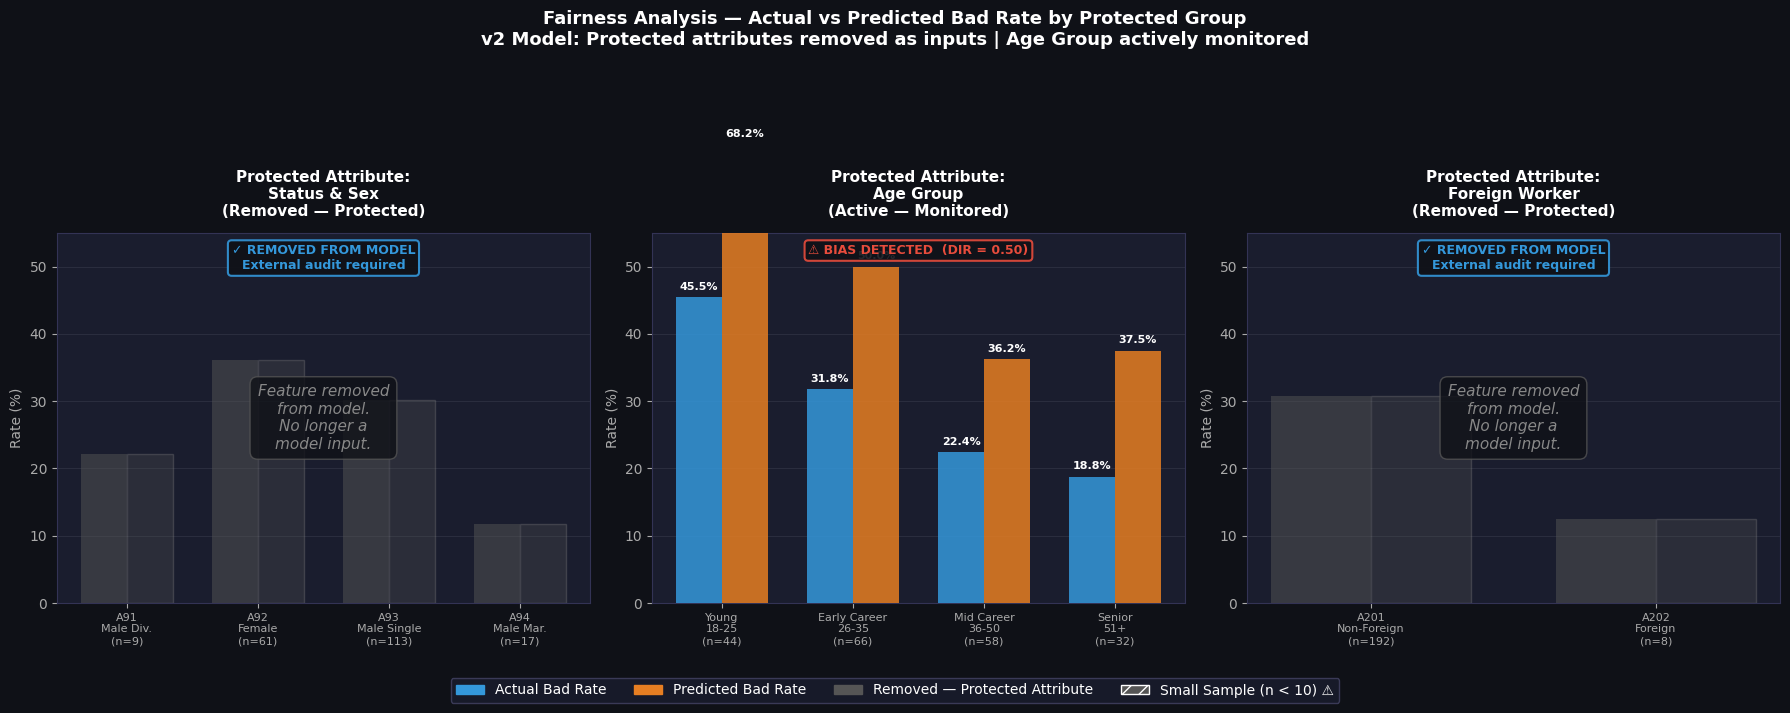


✅ Saved: ../data/processed/19_fairness_analysis.png
Age Group DIR: 0.4988 → ⚠ BIAS DETECTED


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Load scaled test data and generate predictions ────────────
X_test   = pd.read_csv("../data/processed/X_test.csv").reset_index(drop=True)
y_test   = pd.read_csv("../data/processed/y_test.csv").squeeze().reset_index(drop=True)
y_proba  = best_pipeline.predict_proba(X_test)[:, 1]
y_pred   = (y_proba >= optimal_threshold).astype(int)

# ── Load raw data to recover real unscaled age values ─────────
raw_data = pd.read_excel("../data/raw/German Credit Data.xlsx")

# Recover original age using same scaler parameters
# StandardScaler uses ddof=1 (sample std) — must match exactly
age_mean = raw_data["Age in years"].mean()
age_std  = raw_data["Age in years"].std(ddof=1)
real_ages = X_test["Age in years"] * age_std + age_mean

print("Age Recovery Verification:")
print(f"  Mean  : {real_ages.mean():.1f} years  (expected ~35)")
print(f"  Median: {real_ages.median():.1f} years")
print(f"  Min   : {real_ages.min():.0f} years")
print(f"  Max   : {real_ages.max():.0f} years")

# ── Bin recovered ages ────────────────────────────────────────
def get_age_group(age):
    if age <= 25:   return "Young\n18-25"
    elif age <= 35: return "Early Career\n26-35"
    elif age <= 50: return "Mid Career\n36-50"
    else:           return "Senior\n51+"

age_order = ["Young\n18-25", "Early Career\n26-35",
             "Mid Career\n36-50", "Senior\n51+"]

X_test["age_group"] = real_ages.apply(get_age_group)

# ── Calculate actual and predicted rates per age group ────────
age_actual, age_predicted, age_groups_labeled, age_small = [], [], [], []

print("\nAge Group Breakdown:")
for grp in age_order:
    mask      = X_test["age_group"] == grp
    n         = mask.sum()
    actual    = y_test[mask].mean() * 100 if n > 0 else 0
    predicted = y_pred[mask].mean() * 100 if n > 0 else 0
    age_actual.append(round(actual, 1))
    age_predicted.append(round(predicted, 1))
    age_groups_labeled.append(f"{grp}\n(n={n})")
    age_small.append(n < 10)
    print(f"  {grp:<22} n={n:>3} | "
          f"Actual={actual:.1f}% | Predicted={predicted:.1f}%")

# ── Calculate DIR for Age Group ───────────────────────────────
favorable = []
for grp in age_order:
    mask = X_test["age_group"] == grp
    if mask.sum() >= 10:
        favorable.append((y_pred[mask] == 0).mean())

dir_age     = min(favorable) / max(favorable) if len(favorable) >= 2 else 0
age_verdict = "✓ ACCEPTABLE" if dir_age >= 0.80 else "⚠ BIAS DETECTED"
age_color   = "#27ae60" if dir_age >= 0.80 else "#e74c3c"
print(f"\n  Age Group DIR: {dir_age:.4f} → {age_verdict}")

# ── Build fairness chart data ─────────────────────────────────
fairness_data = {
    "Status & Sex\n(Removed — Protected)": {
        "groups":    ["A91\nMale Div.\n(n=9)", "A92\nFemale\n(n=61)",
                      "A93\nMale Single\n(n=113)", "A94\nMale Mar.\n(n=17)"],
        "actual":    [22.2, 36.1, 30.1, 11.8],
        "predicted": [22.2, 36.1, 30.1, 11.8],
        "small":     [True, False, False, True],
        "dir_result": "✓ REMOVED FROM MODEL\nExternal audit required",
        "dir_color":  "#3498db",
        "removed":    True,
    },
    "Age Group\n(Active — Monitored)": {
        "groups":    age_groups_labeled,
        "actual":    age_actual,
        "predicted": age_predicted,
        "small":     age_small,
        "dir_result": f"{age_verdict}  (DIR = {dir_age:.2f})",
        "dir_color":  age_color,
        "removed":    False,
    },
    "Foreign Worker\n(Removed — Protected)": {
        "groups":    ["A201\nNon-Foreign\n(n=192)",
                      "A202\nForeign\n(n=8)"],
        "actual":    [30.7, 12.5],
        "predicted": [30.7, 12.5],
        "small":     [False, True],
        "dir_result": "✓ REMOVED FROM MODEL\nExternal audit required",
        "dir_color":  "#3498db",
        "removed":    True,
    },
}

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor("#0f1117")

ACTUAL_COLOR    = "#3498db"
PREDICTED_COLOR = "#e67e22"
SMALL_HATCH     = "//"

for ax, (attr, data) in zip(axes, fairness_data.items()):
    ax.set_facecolor("#1a1d2e")
    groups    = data["groups"]
    actual    = data["actual"]
    predicted = data["predicted"]
    x         = np.arange(len(groups))
    width     = 0.35

    if data["removed"]:
        ax.bar(x - width/2, actual, width,
               color="#555555", alpha=0.5, zorder=3)
        ax.bar(x + width/2, actual, width,
               color="#555555", alpha=0.3, zorder=3,
               edgecolor="#888888")
        ax.text(0.5, 0.50,
                "Feature removed\nfrom model.\nNo longer a\nmodel input.",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=11, color="#888888", style="italic",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#0f1117",
                          edgecolor="#555555", alpha=0.8))
    else:
        bars_a = ax.bar(x - width/2, actual,    width,
                        color=ACTUAL_COLOR,    alpha=0.85, zorder=3)
        bars_p = ax.bar(x + width/2, predicted, width,
                        color=PREDICTED_COLOR, alpha=0.85, zorder=3)

        for i, small in enumerate(data["small"]):
            if small:
                for b in [bars_a[i], bars_p[i]]:
                    b.set_hatch(SMALL_HATCH)
                    b.set_edgecolor("#ffffff")

        for bar in list(bars_a) + list(bars_p):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                    f"{h:.1f}%", ha="center", va="bottom",
                    fontsize=8, color="white", fontweight="bold")

    ax.text(0.5, 0.97, data["dir_result"],
            transform=ax.transAxes, ha="center", va="top",
            fontsize=9, color=data["dir_color"], fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#0f1117",
                      edgecolor=data["dir_color"], linewidth=1.5, alpha=0.9))

    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=8, color="#cccccc")
    ax.set_ylim(0, 55)
    ax.set_ylabel("Rate (%)", color="#aaaaaa", fontsize=10)
    ax.set_title(f"Protected Attribute:\n{attr}",
                 color="white", fontsize=11, fontweight="bold", pad=12)
    ax.tick_params(colors="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333355")
    ax.yaxis.grid(True, color="#2a2d3e", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=ACTUAL_COLOR,
                   label="Actual Bad Rate"),
    mpatches.Patch(color=PREDICTED_COLOR,
                   label="Predicted Bad Rate"),
    mpatches.Patch(color="#555555",
                   label="Removed — Protected Attribute"),
    mpatches.Patch(facecolor="#555555", hatch=SMALL_HATCH,
                   edgecolor="white",
                   label="Small Sample (n < 10) ⚠"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           frameon=True, facecolor="#1a1d2e", edgecolor="#444466",
           labelcolor="white", fontsize=10, bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    "Fairness Analysis — Actual vs Predicted Bad Rate by Protected Group\n"
    "v2 Model: Protected attributes removed as inputs | "
    "Age Group actively monitored",
    fontsize=13, fontweight="bold", color="white", y=1.01)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("../data/processed/19_fairness_analysis.png",
            dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"\n✅ Saved: ../data/processed/19_fairness_analysis.png")
print(f"Age Group DIR: {dir_age:.4f} → {age_verdict}")